# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset Telco Customer Churn adalah dataset publik yang disediakan oleh IBM melalui platform Kaggle. Dataset ini berisi data fiktif mengenai perusahaan telekomunikasi yang menyediakan layanan rumahan untuk 7.043 pelanggan di California pada kuartal ketiga. Dataset ini sangat populer digunakan untuk melatih model klasifikasi guna memprediksi customer churn (kecenderungan pelanggan untuk berhenti berlangganan atau meninggalkan penyedia layanan)


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [14]:
# Import library dasar untuk manipulasi data dan komputasi
import pandas as pd
import numpy as np

# Import library untuk visualisasi data
import matplotlib.pyplot as plt
import seaborn as sns

# Import library untuk preprocessing dan pembagian data
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

print("Library berhasil di-import!")

Library berhasil di-import!


# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [15]:
# Memuat dataset Telco Customer Churn
# Pastikan nama file sesuai dengan yang kamu unggah di session Colab (misal: WA_Fn-UseC_-Telco-Customer-Churn.csv)
# Tambahkan huruf r di depan tanda kutip
df = pd.read_csv(r"D:\SMSML_Nero Caesar Suprobo\Eksperimen_SML_Nero\namadataset_raw\telco_churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

--- Informasi Struktur Data ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessB

C:\Users\ACER\AppData\Local\Temp\ipykernel_7044\809004600.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Churn', data=df, palette='Set2')


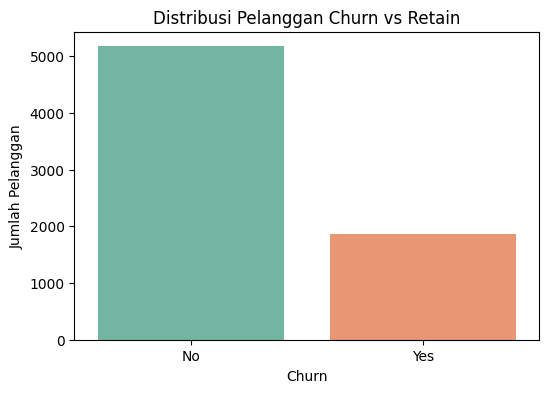

In [16]:
# 1. Memeriksa ringkasan struktur data dan tipe tiap kolom
print("--- Informasi Struktur Data ---")
df.info()

# 2. Memeriksa ringkasan statistik untuk fitur numerik
print("\n--- Ringkasan Statistik Numerik ---")
print(df.describe())

# 3. Memeriksa rasio/distribusi kelas pada target 'Churn'
print("\n--- Distribusi Kelas Churn ---")
print(df['Churn'].value_counts())

# Visualisasi distribusi target Churn agar terlihat proporsinya
plt.figure(figsize=(6,4))
sns.countplot(x='Churn', data=df, palette='Set2')
plt.title('Distribusi Pelanggan Churn vs Retain')
plt.xlabel('Churn')
plt.ylabel('Jumlah Pelanggan')
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [17]:
# 1. Menghapus kolom yang tidak diperlukan untuk pemodelan (customerID)
if 'customerID' in df.columns:
    df.drop(columns=['customerID'], inplace=True)

# 2. Menangani anomali dan missing value pada kolom TotalCharges
# Mengubah spasi kosong (" ") menjadi NaN (Not a Number) agar terdeteksi sebagai missing value
df['TotalCharges'] = df['TotalCharges'].replace(" ", np.nan)

# Mengubah tipe data TotalCharges dari object (teks) menjadi float (angka desimal)
df['TotalCharges'] = df['TotalCharges'].astype(float)

# Mengisi nilai yang kosong (NaN) tersebut dengan nilai MEDIAN dari kolom TotalCharges
median_total_charges = df['TotalCharges'].median()
df['TotalCharges'].fillna(median_total_charges, inplace=True)

# 3. Menghapus baris data yang duplikat (jika ada)
df.drop_duplicates(inplace=True)

# 4. Encoding Variabel Kategorikal
# Mengubah kolom target 'Churn' menjadi biner (Yes -> 1, No -> 0)
le = LabelEncoder()
df['Churn'] = le.fit_transform(df['Churn'])

# Mengubah fitur kategori teks lainnya menjadi angka menggunakan One-Hot Encoding
categorical_cols = df.select_dtypes(include=['object']).columns
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# 5. MENYIMPAN DATA BERSIH
# File ini yang akan menjadi bahan utama untuk script otomatisasi 'modelling.py' nanti
df.to_csv("clean_data.csv", index=False)

print("Proses Data Preprocessing Selesai!")
print(f"Dimensi data akhir (Baris, Kolom): {df.shape}")
print("Berkas 'clean_data.csv' berhasil disimpan di folder lokal kamu.")

C:\Users\ACER\AppData\Local\Temp\ipykernel_7044\1376735904.py:14: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(median_total_charges, inplace=True)


Proses Data Preprocessing Selesai!
Dimensi data akhir (Baris, Kolom): (7021, 31)
Berkas 'clean_data.csv' berhasil disimpan di folder lokal kamu.
